In [1]:
import sys
import os
import pandas as pd

# Find the project root (Speciale_Kode)
current_dir = os.getcwd()
project_root = current_dir

# Looks for "Speciale_Kode" folder:
while os.path.basename(project_root) != "Speciale_Kode":
    project_root = os.path.dirname(project_root)

# Add to Python path
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
new_results_folder = os.path.join(project_root, "Shallow learners - phase 2", "Random Forest", "Old_final_eval")

og_results_folder = os.path.join(project_root, "Predictions+Results", "Predictions")
og_results_DK1 = os.path.join(og_results_folder, "DK1")
og_results_DK2 = os.path.join(og_results_folder, "DK2")

In [3]:
new_DK1_file = os.path.join(new_results_folder, "DK1_RandomForest_multi_predictions.csv")
new_DK2_file = os.path.join(new_results_folder, "DK2_RandomForest_multi_predictions.csv")
new_DK1_df = pd.read_csv(new_DK1_file, sep = ",", decimal = ".")
new_DK2_df = pd.read_csv(new_DK2_file, sep = ",", decimal = ".")

og_DK1_file = os.path.join(og_results_DK1, "RandomForest.csv")
og_DK2_file = os.path.join(og_results_DK2, "RandomForest.csv")
og_DK1_df = pd.read_csv(og_DK1_file, sep = ",", decimal = ".")
og_DK2_df = pd.read_csv(og_DK2_file, sep = ",", decimal = ".")

In [4]:
column = "Time"

xpoints = new_DK1_df[column].values.tolist()

column = "Prediction"

new_DK1_predictions = new_DK1_df[column].values.tolist()
new_DK2_predictions = new_DK2_df[column].values.tolist()

In [5]:
column = "DKPrice"

actuals_list = new_DK1_df[column].values.tolist()

In [6]:
n = 24

og_DK1_df.drop(og_DK1_df.tail(n).index, inplace = True)
og_DK2_df.drop(og_DK2_df.tail(n).index, inplace = True)

In [7]:
column = "Prediction"

og_DK1_predictions = og_DK1_df[column].values.tolist()
og_DK2_predictions = og_DK2_df[column].values.tolist()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

price_zone = "DK1"

if price_zone == "DK1":
    og_predictions = og_DK1_predictions
    new_predictions = new_DK1_predictions
else:
    og_predictions = og_DK2_predictions
    new_predictions = new_DK2_predictions

plt.figure(figsize=(30, 5))
plt.plot(xpoints, actuals_list, label = "Actual prices")
#plt.plot(xpoints, og_predictions, label = "Original Predictions")
plt.plot(xpoints, new_predictions, label = "New Predictions")
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.xlabel('Prediction Day')
plt.ylabel('Price (DKK/MWh)')
plt.title(f'Comparison of Price Predictions for Random Forest for the New Model for {price_zone} along with the Actual Prices')
plt.legend()
plt.tight_layout()
plt.savefig(f"RandomForest_Prices_{price_zone}")
plt.show()

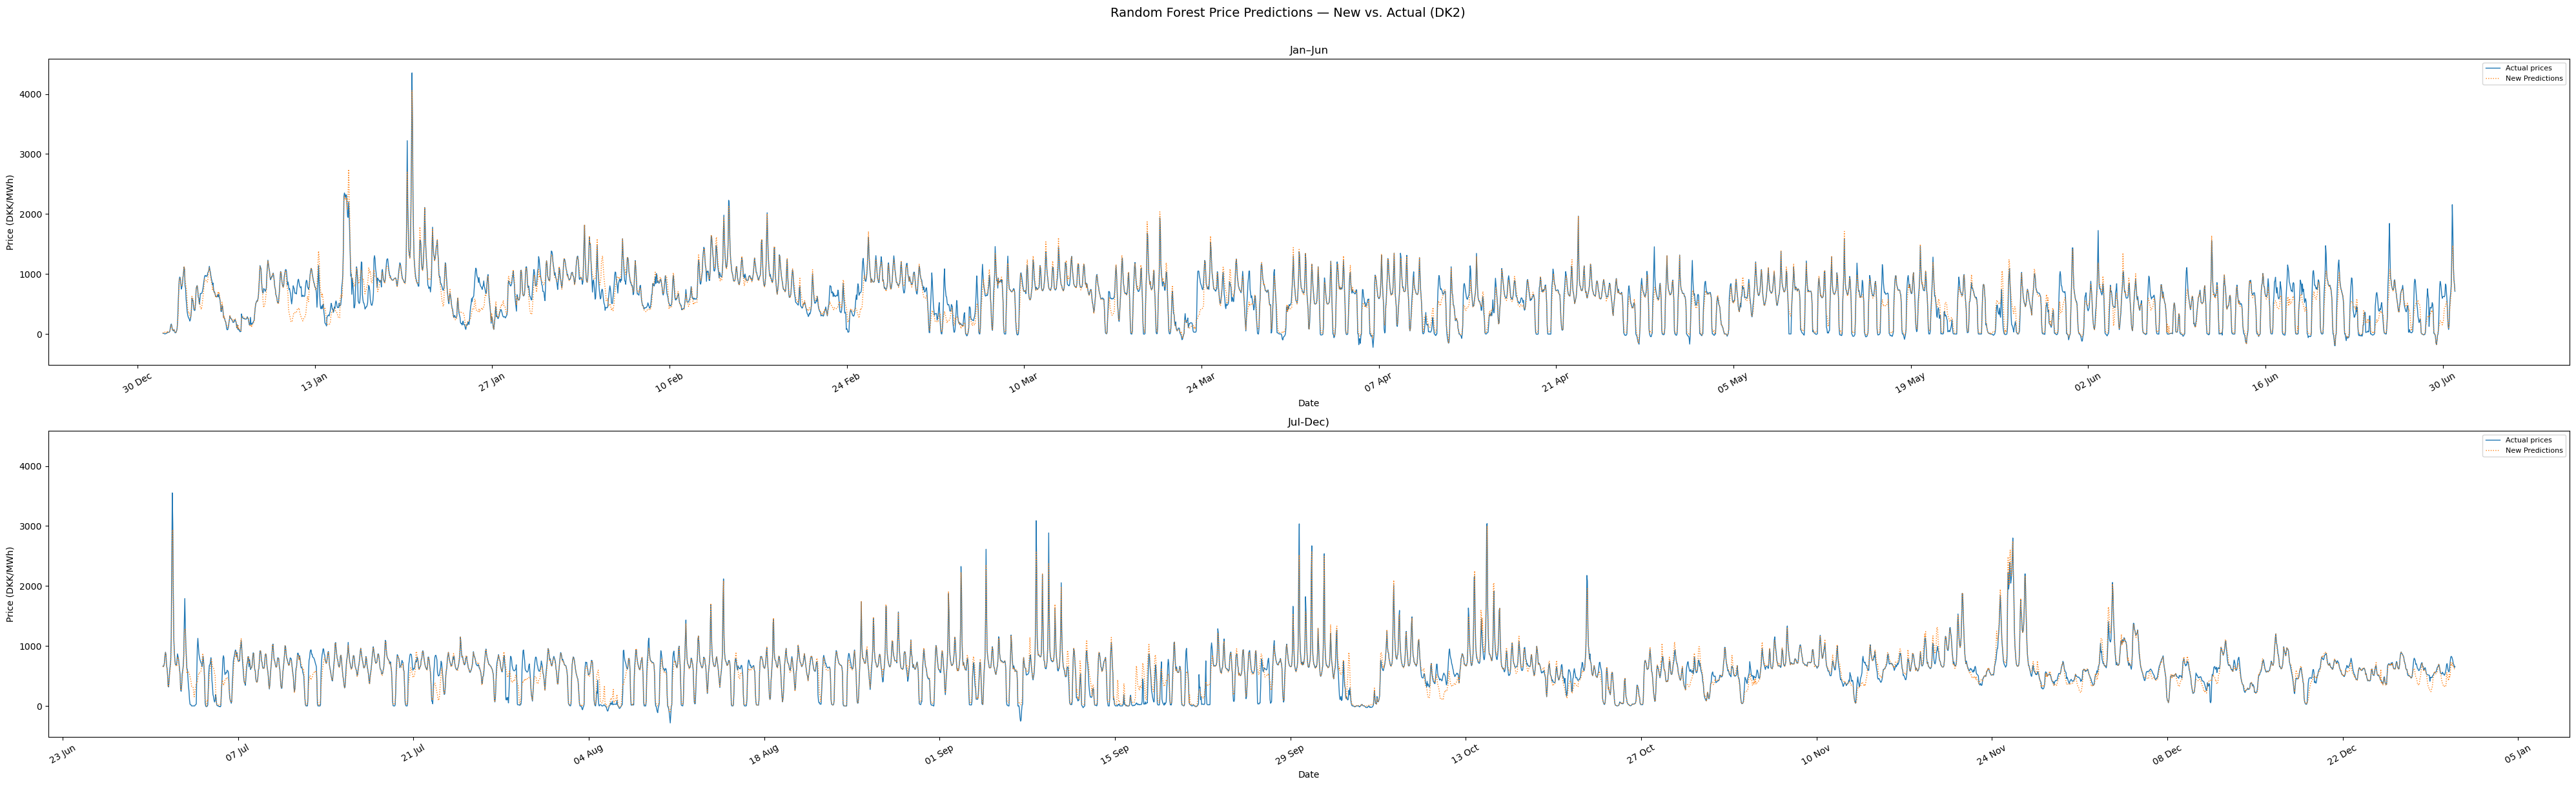

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

price_zone = "DK2"

if price_zone == "DK1":
    og_predictions = og_DK1_predictions
    new_predictions = new_DK1_predictions
else:
    og_predictions = og_DK2_predictions
    new_predictions = new_DK2_predictions

# Build a DataFrame for easy slicing
plot_df = pd.DataFrame({
    "Date": pd.to_datetime(xpoints),
    "Actual": actuals_list,
#    "Original": og_predictions,
    "New": new_predictions,
})

quarters = {
    "Jan–Jun": (1, 6),
    "Jul-Dec)": (7, 12),
}

fig, axes = plt.subplots(2, 1, figsize=(40, 12), sharey=True)
axes = axes.flatten()

for ax, (q_label, (m_start, m_end)) in zip(axes, quarters.items()):
    mask = (plot_df["Date"].dt.month >= m_start) & (plot_df["Date"].dt.month <= m_end)
    q_df = plot_df[mask]

    ax.plot(q_df["Date"], q_df["Actual"],   label="Actual prices",        linewidth=1.0)
#    ax.plot(q_df["Date"], q_df["Original"], label="Original Predictions",  linewidth=1.0, linestyle="--")
    ax.plot(q_df["Date"], q_df["New"],      label="New Predictions",        linewidth=1.0, linestyle=":")

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(q_label)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (DKK/MWh)")
    ax.legend(fontsize=8)

fig.suptitle(
    f"Random Forest Price Predictions — New vs. Actual ({price_zone})",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig(f"RandomForest_Prices_{price_zone}_quarterly.png", dpi=150, bbox_inches="tight")
plt.show()